In this notebook we recreate the plots that were presented in 'Cosmological perturbations with ultralight vector dark matter fields: numerical implementation in CLASS'.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
from scipy.interpolate import interp1d

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

#%matplotlib widget

### LCDM

In [2]:
# Planck 2018  Cosmological parameters

h_planck = 0.6688              # TT,TE,EE+lowE
omega_m = 0.321*h_planck**2   # TT,TE,EE+lowE
omega_cdm = 0.1206            # TT,TE,EE+lowE
Omega_Lambda = 0.679          # TT,TE,EE+lowE
omega_b = 0.02212              # TT,TE,EE+lowE
tau_reio = 0.05522              # TT,TE,EE+lowE
As = 2.092 * 1.e-9             # TT,TE,EE+lowE
ns = 0.962                    # TT,TE,EE+lowE
theta_s = 1.04077              # TT,TE,EE+lowE


In [3]:
colors = ['#3C536D', '#DAC746', '#6E6F6D', '#DC4D57']
masses =  [1.e-25, 1.e-24, 1.e-23, 1.e-20] # eV
masses_Mpc = [mass*1.56373846613383*1.e29 for mass in masses]# Mpc^-1

# Precision overrides (previously hard-coded in include/precisions.h, now set per-notebook)
precision_settings = {
    'start_small_k_at_tau_c_over_tau_h': 0.0004,
    'start_large_k_at_tau_h_over_tau_k': 0.001,
    'tol_perturbations_integration': 1.e-8,
    'k_per_decade_primordial': 30.0,
}

lcdm = Class()
lcdm_settings = {'output':'tCl mPk mTk',
                 'omega_b':omega_b,
                 'Omega_cdm' : omega_cdm/h_planck**2, 'Omega_vf' : 0., 
                 'h' : h_planck,#'100*theta_s': theta_s,
                 'A_s' : As,
                 'n_s':ns,
                 'tau_reio':tau_reio,
                 'YHe': 'BBN','gauge':'synchronous',
                 'ic' : 'ad', 'P_k_max_h/Mpc' : 1,
                 'modes' : 's', 'recombination' : 'RECFAST'}
lcdm_settings.update(precision_settings)
lcdm.set(lcdm_settings)

lcdm.compute()
all_k_lcdm = lcdm.get_perturbations()
background_lcdm = lcdm.get_background()
transfer_lcdm = lcdm.get_transfer()


frac = 1-1.e-6
common_settings  = {
            'h' : h_planck, 
            'omega_b' : omega_b,
            'Omega_cdm' : omega_cdm*(1-frac)/h_planck**2,
            'N_ncdm' : 0.,
            'Omega_fld' : 0.,
            'Omega_vf' : frac*omega_cdm/h_planck**2,
            'attractor_ic_vf' : 'yes',
            'vector_background_mode': 'bianchi',
            'YHe' : 'BBN',
            'tau_reio':tau_reio,
            'ic' : 'ad',
            'gauge' : 'synchronous',
            'A_s' : As,
            'n_s' : ns,
            'modes' : 's',
            'recombination' : 'RECFAST',
            'output' : 'tCl mPk mTk',
            'P_k_max_h/Mpc' : 1
            } 
common_settings.update(precision_settings)

As a benchmark, let's define the LCDM cosmology.

## Transfers VFDM

In [4]:
mass = 1.e-25
z0=0
cosmo_angles = {}
angles = [0, np.pi/8, np.pi/4, np.pi/2]
angles_label = ['0', 'π/8', 'π/4', 'π/2']
mass_Mpc = mass*1.56373846613383*1.e29
color_angles = ['b','red','olive','orange']

for m in range(len(angles)):

    cosmo_angles[m] = Class()
    cosmo_angles[m].set(common_settings)
    cosmo_angles[m].set({'gamma_Ak' : angles[m]})
    cosmo_angles[m].set({'svt_coupling' : 'no'})
    cosmo_angles[m].set({'vf_mass' : '%s'%mass})
    cosmo_angles[m].compute()

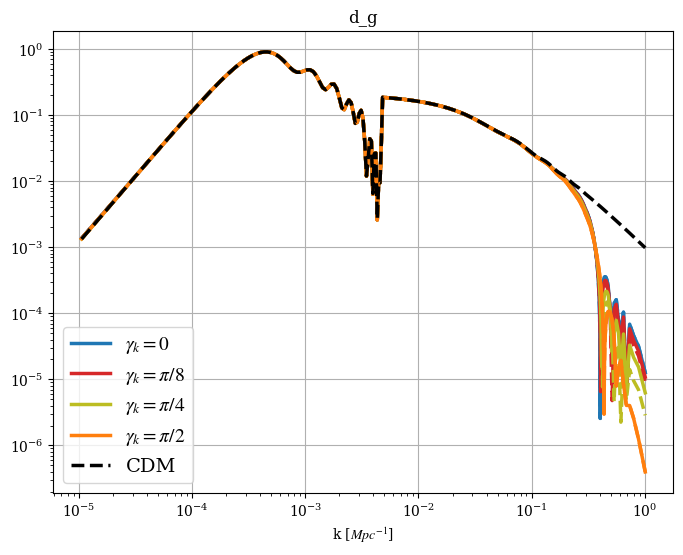

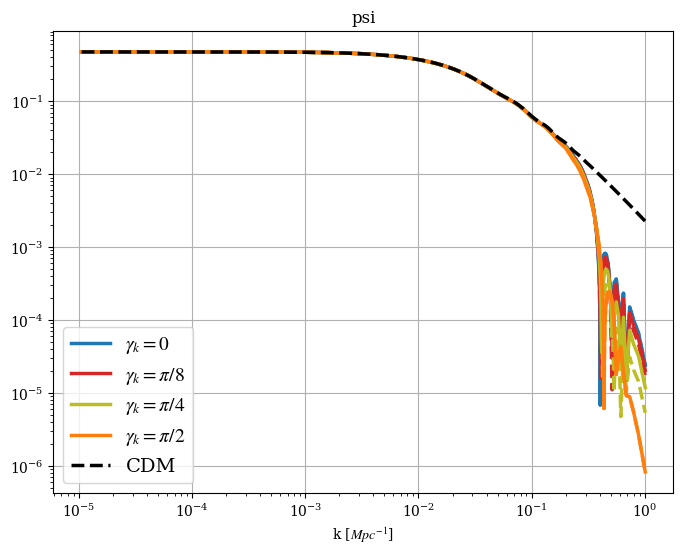

In [5]:
# m = 10^{-25} eV
color_angles = ['tab:blue','tab:red','tab:olive', 'tab:orange']
def Transfer_z0(z0, string):

    transfer_g_lcdm = transfer_lcdm[string]
    kk_lcdm = transfer_lcdm['k (h/Mpc)']

    plt.figure(figsize=(8,6))
    for m in range(len(angles)):
        # K_J
        transfer = cosmo_angles[m].get_transfer()
        kk = transfer['k (h/Mpc)']
        transfer_g = transfer[string]

        for k in kk:
            transfer0 = cosmo_angles[0].get_transfer()
            transferpi2 = cosmo_angles[len(angles)-1].get_transfer()
        array_fit = transferpi2[string] + (transfer0[string]-transferpi2[string]) * np.cos(angles[m])**(4) 
        
        #Plot the Matter Power Spectrum
        plt.loglog(kk, np.abs(transfer_g), color_angles[m], label=r'$\gamma_k=%s$'% str(angles_label[m]), lw=2.5)
        plt.loglog(kk, np.abs(array_fit), color_angles[m], linestyle='dashed', lw=2.5)
        if angles[m] == angles[-1]:
            plt.loglog(kk_lcdm, np.abs(transfer_g_lcdm), 'k--', label=r'CDM', lw=2.5)
            plt.legend(loc='lower left',fontsize=14)
    plt.xlabel('k [$Mpc^{-1}$]')
    plt.title(str(string))
    plt.grid()
    plt.show()


Transfer_z0(0, 'd_g')
Transfer_z0(0, 'psi')

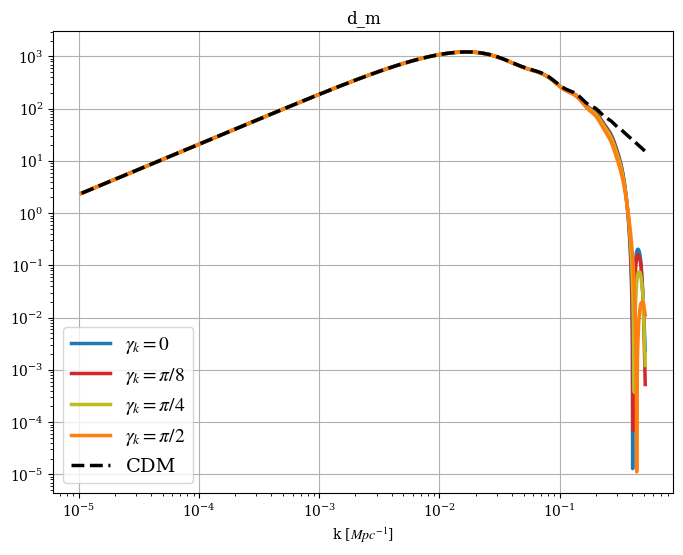

In [6]:
color_angles = ['tab:blue','tab:red','tab:olive', 'tab:orange']
def Transfer_z0(z0, string):

    transfer_g_lcdm = transfer_lcdm[string]
    kk_lcdm = transfer_lcdm['k (h/Mpc)']

    plt.figure(figsize=(8,6))
    for m in range(len(angles)):
        # K_J
        transfer = cosmo_angles[m].get_transfer()
        transfer, prim = cosmo_angles[m].get_transfer(), cosmo_angles[m].get_primordial()
        kk = transfer['k (h/Mpc)']
        transfer_g = transfer[string]
        primordial_k = prim['k [1/Mpc]']
        primordial = prim['P_scalar(k)']
        primordial_interp = interp1d(primordial_k, primordial)
        for k in kk:
            transfer0 = cosmo_angles[0].get_transfer()
            transferpi2 = cosmo_angles[len(angles)-1].get_transfer()
        array_fit = transferpi2[string] + (transfer0[string]-transferpi2[string]) * np.cos(angles[m])**(4) 
        
        #Plot the Matter Power Spectrum
        plt.loglog(kk[:-10], np.abs(transfer_g[:-10]**2 * primordial_interp(kk[:-10]))/kk[:-10]**3, color_angles[m], label=r'$\gamma_k=%s$'% str(angles_label[m]), lw=2.5)
        #plt.loglog(kk, np.abs(array_fit), color_angles[m], linestyle='dashed', lw=2.5)
        if angles[m] == angles[-1]:
            plt.loglog(kk_lcdm[:-10], np.abs(transfer_g_lcdm[:-10]**2 * primordial_interp(kk[:-10]))/kk[:-10]**3, 'k--', label=r'CDM', lw=2.5)
            plt.legend(loc='lower left',fontsize=14)
    plt.xlabel('k [$Mpc^{-1}$]')
    plt.title(str(string))
    plt.grid()
    plt.show()


Transfer_z0(0, 'd_m')

## Comparison  VFDM-SFDM-LCDM

In [7]:
cosmo0 = {}
cosmopi2 = {}
for m in range(len(masses)):

    cosmo0[m] = Class()
    cosmo0[m].set(common_settings)
    cosmo0[m].set({'vf_mass' : '%s'%masses[m]})
    cosmo0[m].set({'vector_background_mode' : 'bianchi'})
    cosmo0[m].set({'svt_coupling' : 'no'})
    cosmo0[m].set({'gamma_Ak': 0})
    cosmo0[m].compute()
    #all_k = M.get_perturbations()

    cosmopi2[m] = Class()
    cosmopi2[m].set(common_settings)
    cosmopi2[m].set({'vf_mass' : '%s'%masses[m]})
    cosmopi2[m].set({'vector_background_mode' : 'bianchi'})
    cosmopi2[m].set({'svt_coupling' : 'no'})
    cosmopi2[m].set({'gamma_Ak': np.pi/2})
    cosmopi2[m].compute()
    #all_k = M.get_perturbations()

    print(masses[m])

1e-25
1e-24
1e-23
1e-20


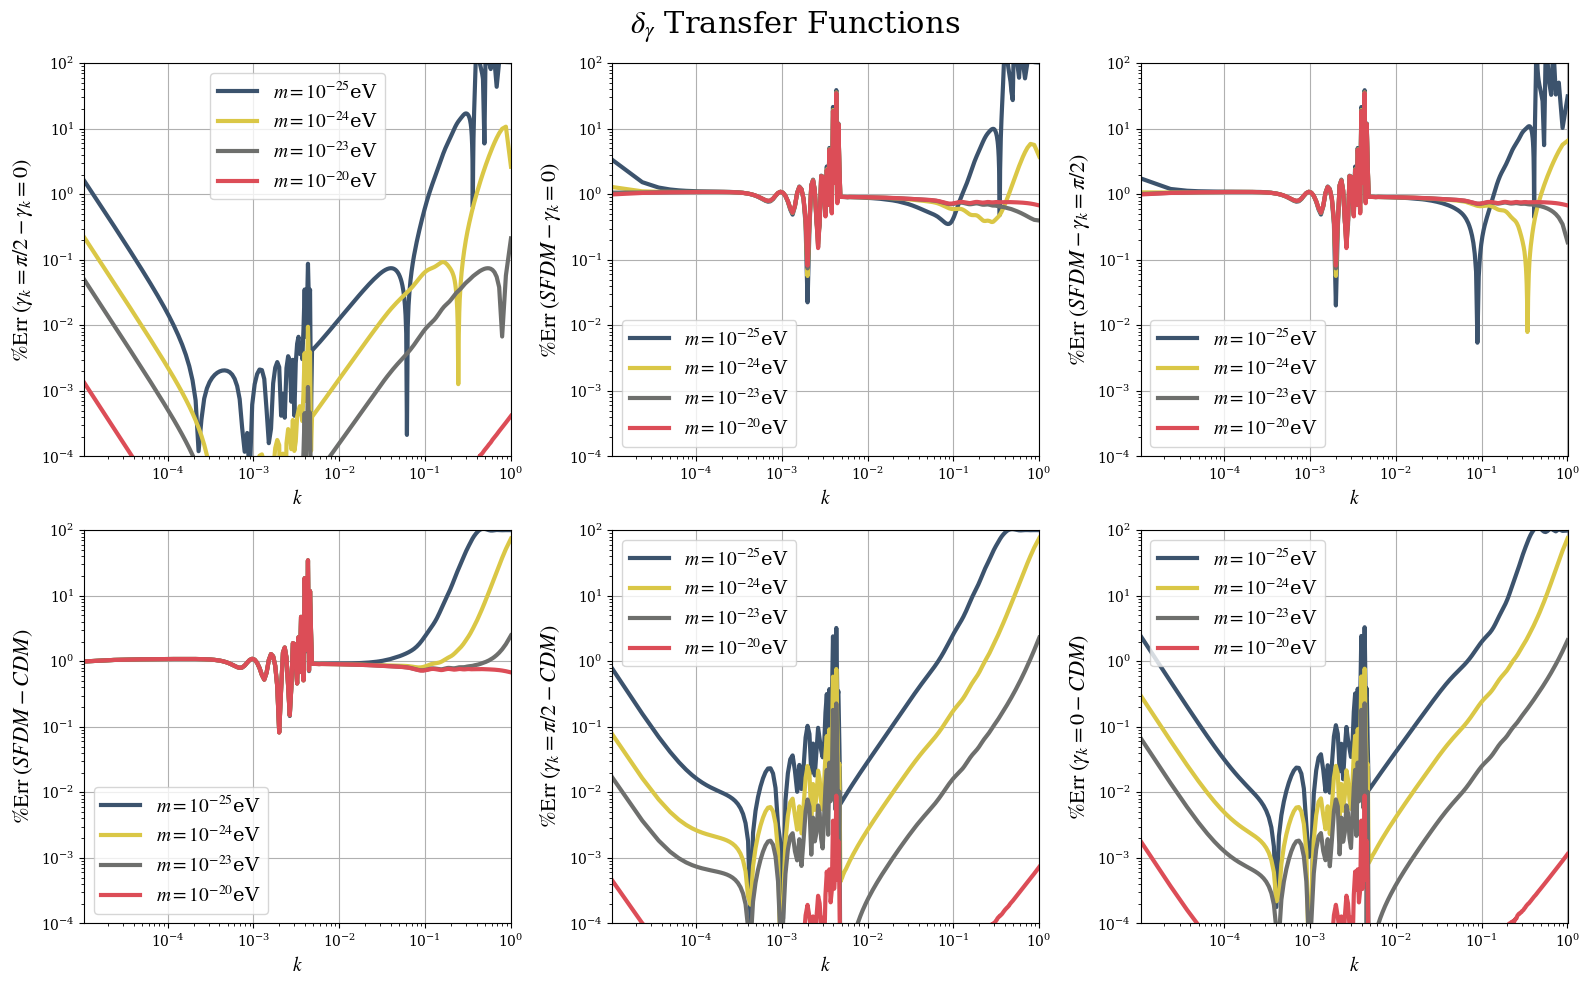

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()   # so we can index axes[m]

def errors(transfer):
    for m in range(len(masses)):

        transfer0 = cosmo0[m].get_transfer()
        transferpi2 = cosmopi2[m].get_transfer()
        transferlcdm = lcdm.get_transfer()
        kk = transfer0['k (h/Mpc)']
        transfer_g0 = transfer0[transfer]
        transfer_gpi2 = transferpi2[transfer]
        transfer_glcdm = transferlcdm[transfer]

        # Compute error
        k_sfdm = np.load('../../SFDM_data/Transfers_sfdm/Transfer_dg_sfdm_m=10^{%s}eV.npz'%str(masses[m])[-3:])['k']
        if transfer=='d_g':
            Transfer_sfdm = np.load('../../SFDM_data/Transfers_sfdm/Transfer_dg_sfdm_m=10^{%s}eV.npz'%str(masses[m])[-3:])['transfer_dg']
            plt.suptitle('$\delta_{\gamma}$ Transfer Functions', fontsize=22)
        elif transfer=='psi':
            Transfer_sfdm = np.load('../../SFDM_data/Transfers_sfdm/Transfer_dg_sfdm_m=10^{%s}eV.npz'%str(masses[m])[-3:])['transfer_psi']
            plt.suptitle('$\psi$ Transfer Functions', fontsize=22)

        err0 = [100 * np.abs(1 - transfer_gpi2[i] / transfer_g0[i]) for i in range(len(transfer_gpi2))]
        err1 = [100 * np.abs(1 - Transfer_sfdm[i] / transfer_g0[i]) for i in range(len(transfer_gpi2))]
        err2 = [100 * np.abs(1 - Transfer_sfdm[i] / transfer_gpi2[i]) for i in range(len(transfer_gpi2))]
        err3 = [100 * np.abs(1 - Transfer_sfdm[i] / transfer_glcdm[i]) for i in range(len(transfer_gpi2))]
        err4 = [100 * np.abs(1 - transfer_gpi2[i] / transfer_glcdm[i]) for i in range(len(transfer_gpi2))]
        err5 = [100 * np.abs(1 - transfer_g0[i] / transfer_glcdm[i]) for i in range(len(transfer_gpi2))]

        # Plot
        axes[0].plot(kk, err0, color=colors[m], label=r'$m=10^{%s}$eV'% str(masses[m])[-3:], lw=3)
        axes[1].plot(kk, err1, color=colors[m], label=r'$m=10^{%s}$eV'% str(masses[m])[-3:], lw=3)
        axes[2].plot(kk, err2, color=colors[m], label=r'$m=10^{%s}$eV'% str(masses[m])[-3:], lw=3)
        axes[3].plot(kk, err3, color=colors[m], label=r'$m=10^{%s}$eV'% str(masses[m])[-3:], lw=3)
        axes[4].plot(kk, err4, color=colors[m], label=r'$m=10^{%s}$eV'% str(masses[m])[-3:], lw=3)
        axes[5].plot(kk, err5, color=colors[m], label=r'$m=10^{%s}$eV'% str(masses[m])[-3:], lw=3)


        axes[0].set_ylabel(r'$\%{\rm Err}\;(\gamma_k=\pi/2 - \gamma_k=0)$', fontsize=16)
        axes[1].set_ylabel(r'$\%{\rm Err}\;(SFDM - \gamma_k=0)$', fontsize=16)
        axes[2].set_ylabel(r'$\%{\rm Err}\;(SFDM - \gamma_k=\pi/2)$', fontsize=16)
        axes[3].set_ylabel(r'$\%{\rm Err}\;(SFDM - CDM)$', fontsize=16)
        axes[4].set_ylabel(r'$\%{\rm Err}\;(\gamma_k=\pi/2 - CDM)$', fontsize=16)
        axes[5].set_ylabel(r'$\%{\rm Err}\;(\gamma_k=0 - CDM)$', fontsize=16)

    for i in range(6):
        ax = axes[i]
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$k$', fontsize=14)
        ax.set_ylim(1.e-4, 1.e2)
        ax.set_xlim(kk[0], kk[-1])
        ax.grid()
        #ax.grid(True, which='both', ls='--', alpha=0.4)
        ax.legend(fontsize=14)

    plt.tight_layout()
    plt.show()

#errors('psi')
errors('d_g')